In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import warnings
warnings.filterwarnings("ignore")


In [36]:
data = pd.read_csv(r'D:\Creditcard_fraud_detection\data\raw\fraudTrain.csv')
# data = pd.read_csv(r'../data/raw/fraudTest.csv')

pd.set_option("display.max_columns",None)
pd.set_option("display.max_rows",100)

data.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0


In [37]:
data.shape

(1296675, 23)

In [38]:
data.dtypes

Unnamed: 0                 int64
trans_date_trans_time        str
cc_num                     int64
merchant                     str
category                     str
amt                      float64
first                        str
last                         str
gender                       str
street                       str
city                         str
state                        str
zip                        int64
lat                      float64
long                     float64
city_pop                   int64
job                          str
dob                          str
trans_num                    str
unix_time                  int64
merch_lat                float64
merch_long               float64
is_fraud                   int64
dtype: object

In [39]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

In [40]:
data_quality = pd.DataFrame({
    "columns" : data.columns,
    "dtype": data.dtypes.astype(str).value_counts,
    "missing values": data.isnull().sum().values,
    "missing percentage": ( data.isnull().mean().values * 100),
    "unique_count": data.nunique().values,
    "duplicates": data.duplicated().sum()
})

data_quality

,columns,dtype,missing values,missing percentage,unique_count,duplicates
0,Unnamed: 0,<bound method IndexOpsMixin.value_counts of Un...,0,0.0,1296675,0
1,trans_date_trans_time,<bound method IndexOpsMixin.value_counts of Un...,0,0.0,1274791,0
2,cc_num,<bound method IndexOpsMixin.value_counts of Un...,0,0.0,983,0
3,merchant,<bound method IndexOpsMixin.value_counts of Un...,0,0.0,693,0
4,category,<bound method IndexOpsMixin.value_counts of Un...,0,0.0,14,0
5,amt,<bound method IndexOpsMixin.value_counts of Un...,0,0.0,52928,0
6,first,<bound method IndexOpsMixin.value_counts of Un...,0,0.0,352,0
7,last,<bound method IndexOpsMixin.value_counts of Un...,0,0.0,481,0
8,gender,<bound method IndexOpsMixin.value_counts of Un...,0,0.0,2,0
9,street,<bound method IndexOpsMixin.value_counts of Un...,0,0.0,983,0


In [41]:
data['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [42]:
target_summary = pd.DataFrame({
    "count": data["is_fraud"].value_counts(),
    "percentage": data["is_fraud"].value_counts(normalize=True) * 100
})

target_summary

,count,percentage
is_fraud,,
0,1289169,99.421135
1,7506,0.578865


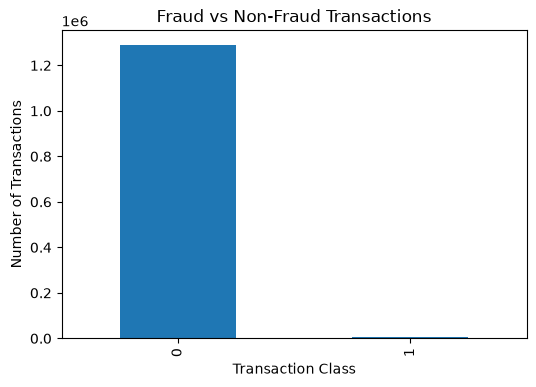

In [43]:
data["is_fraud"].value_counts().plot(kind="bar",figsize=(6, 4))

plt.title("Fraud vs Non-Fraud Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")
plt.show()

In [44]:
numeric_col = data.select_dtypes(include=["int64","float64"]).columns.tolist()
categorial_col = data.select_dtypes(include=["object", "category", "string"]).columns.tolist()

print("Numerical col")
print(numeric_col)
print("categorial_col")
print(categorial_col)

Numerical col
['Unnamed: 0', 'cc_num', 'amt', 'zip', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long', 'is_fraud']
categorial_col
['trans_date_trans_time', 'merchant', 'category', 'first', 'last', 'gender', 'street', 'city', 'state', 'job', 'dob', 'trans_num']


In [45]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1296675 entries, 0 to 1296674
Data columns (total 23 columns):
 #   Column                 Non-Null Count    Dtype  
---  ------                 --------------    -----  
 0   Unnamed: 0             1296675 non-null  int64  
 1   trans_date_trans_time  1296675 non-null  str    
 2   cc_num                 1296675 non-null  int64  
 3   merchant               1296675 non-null  str    
 4   category               1296675 non-null  str    
 5   amt                    1296675 non-null  float64
 6   first                  1296675 non-null  str    
 7   last                   1296675 non-null  str    
 8   gender                 1296675 non-null  str    
 9   street                 1296675 non-null  str    
 10  city                   1296675 non-null  str    
 11  state                  1296675 non-null  str    
 12  zip                    1296675 non-null  int64  
 13  lat                    1296675 non-null  float64
 14  long                   129667

In [46]:
data["amt"].describe()

count    1.296675e+06
mean     7.035104e+01
std      1.603160e+02
min      1.000000e+00
25%      9.650000e+00
50%      4.752000e+01
75%      8.314000e+01
max      2.894890e+04
Name: amt, dtype: float64

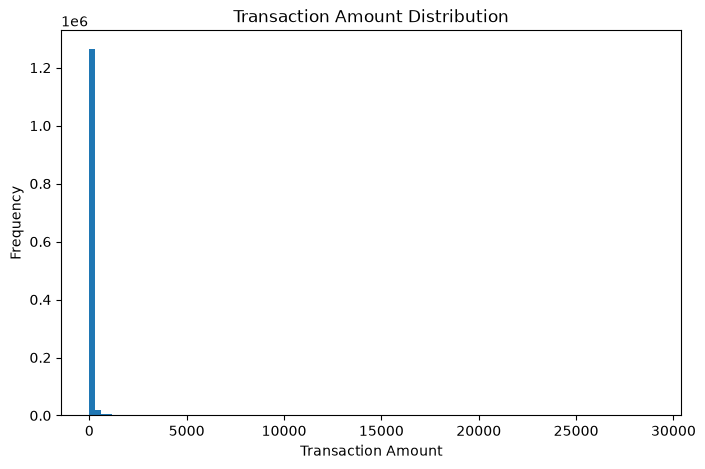

In [47]:
plt.figure(figsize=(8, 5))

plt.hist(data["amt"], bins=100)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

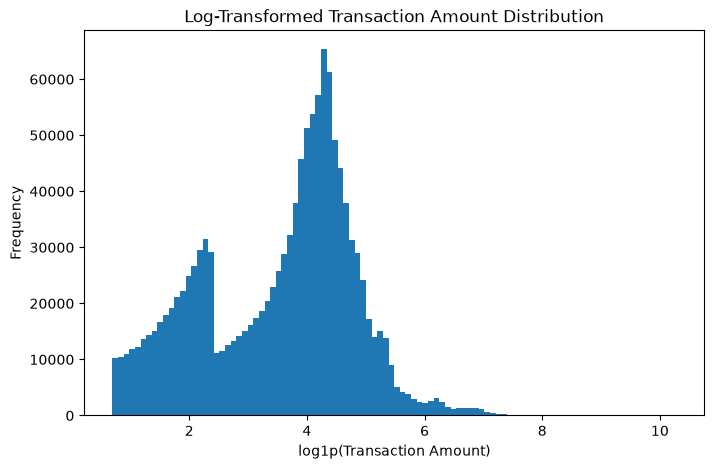

In [48]:
plt.figure(figsize=(8, 5))

plt.hist(np.log1p(data["amt"]), bins=100)

plt.title("Log-Transformed Transaction Amount Distribution")
plt.xlabel("log1p(Transaction Amount)")
plt.ylabel("Frequency")

plt.show()

In [49]:
data[numeric_col].describe().T

,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,1296675.0,6.483370e+05,3.743180e+05,0.000000e+00,3.241685e+05,6.483370e+05,9.725055e+05,1.296674e+06
cc_num,1296675.0,4.171920e+17,1.308806e+18,6.041621e+10,1.800429e+14,3.521417e+15,4.642255e+15,4.992346e+18
amt,1296675.0,7.035104e+01,1.603160e+02,1.000000e+00,9.650000e+00,4.752000e+01,8.314000e+01,2.894890e+04
zip,1296675.0,4.880067e+04,2.689322e+04,1.257000e+03,2.623700e+04,4.817400e+04,7.204200e+04,9.978300e+04
lat,1296675.0,3.853762e+01,5.075808e+00,2.002710e+01,3.462050e+01,3.935430e+01,4.194040e+01,6.669330e+01
long,1296675.0,-9.022634e+01,1.375908e+01,-1.656723e+02,-9.679800e+01,-8.747690e+01,-8.015800e+01,-6.795030e+01
city_pop,1296675.0,8.882444e+04,3.019564e+05,2.300000e+01,7.430000e+02,2.456000e+03,2.032800e+04,2.906700e+06
unix_time,1296675.0,1.349244e+09,1.284128e+07,1.325376e+09,1.338751e+09,1.349250e+09,1.359385e+09,1.371817e+09
merch_lat,1296675.0,3.853734e+01,5.109788e+00,1.902779e+01,3.473357e+01,3.936568e+01,4.195716e+01,6.751027e+01
merch_long,1296675.0,-9.022646e+01,1.377109e+01,-1.666712e+02,-9.689728e+01,-8.743839e+01,-8.023680e+01,-6.695090e+01


In [50]:
data.groupby("is_fraud")["amt"].describe()

,count,mean,std,min,25%,50%,75%,max
is_fraud,,,,,,,,
0,1289169.0,67.667110,154.007971,1.00,9.6100,47.280,82.540,28948.90
1,7506.0,531.320092,390.560070,1.06,245.6625,396.505,900.875,1376.04


In [51]:
data.groupby("is_fraud")["amt"].median()

is_fraud
0     47.280
1    396.505
Name: amt, dtype: float64

In [52]:
data["category"].value_counts()

category
gas_transport     131659
grocery_pos       123638
home              123115
shopping_pos      116672
kids_pets         113035
shopping_net       97543
entertainment      94014
food_dining        91461
personal_care      90758
health_fitness     85879
misc_pos           79655
misc_net           63287
grocery_net        45452
travel             40507
Name: count, dtype: int64

In [53]:
data.groupby("category")["is_fraud"].sum().sort_values(ascending=False)

category
grocery_pos       1743
shopping_net      1713
misc_net           915
shopping_pos       843
gas_transport      618
misc_pos           250
kids_pets          239
entertainment      233
personal_care      220
home               198
food_dining        151
grocery_net        134
health_fitness     133
travel             116
Name: is_fraud, dtype: int64

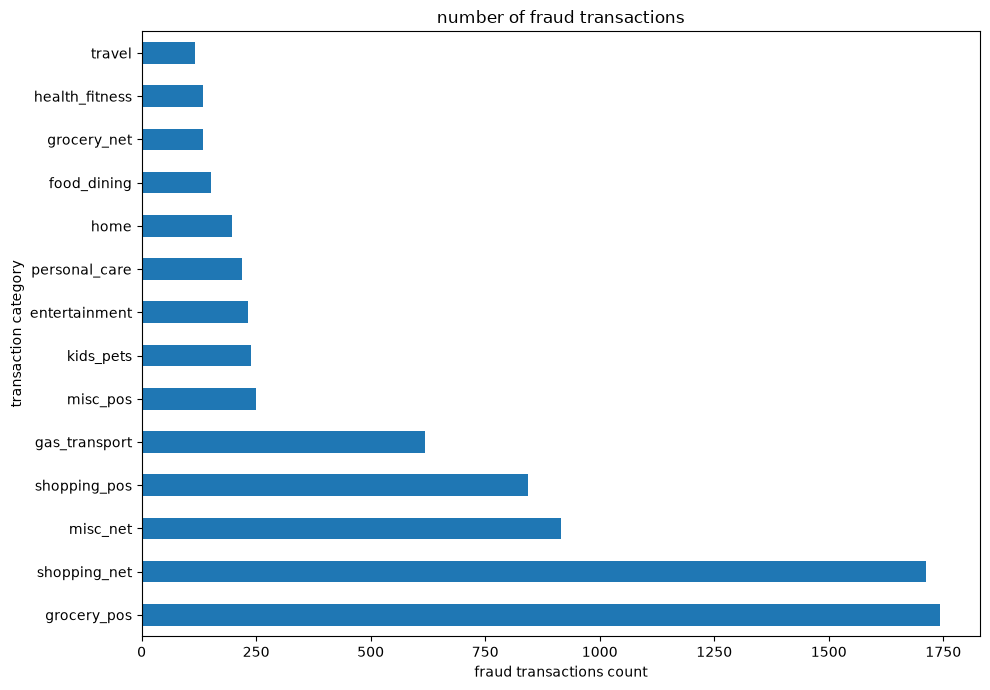

In [54]:
fraud_by_category = (data.groupby("category")["is_fraud"].sum().sort_values(ascending=False))
plt.figure(figsize=(10,7))
fraud_by_category.plot(kind="barh")

plt.title("number of fraud transactions")
plt.xlabel("fraud transactions count")
plt.ylabel("transaction category")

plt.tight_layout()
plt.show()

In [55]:
fraud_by_category_stats = (
    data.groupby("category")["is_fraud"]
      .agg(["count", "sum", "mean"])
      .sort_values("mean", ascending=False)
)

fraud_by_category_stats["fraud_rate_percent"] = (
    fraud_by_category_stats["mean"] * 100
)

fraud_by_category_stats

,count,sum,mean,fraud_rate_percent
category,,,,
shopping_net,97543,1713,0.017561,1.756149
misc_net,63287,915,0.014458,1.445795
grocery_pos,123638,1743,0.014098,1.409761
shopping_pos,116672,843,0.007225,0.722538
gas_transport,131659,618,0.004694,0.469394
misc_pos,79655,250,0.003139,0.313853
grocery_net,45452,134,0.002948,0.294817
travel,40507,116,0.002864,0.286370
entertainment,94014,233,0.002478,0.247835


In [56]:
data["gender"].value_counts()

gender
F    709863
M    586812
Name: count, dtype: int64

In [57]:
data.groupby("gender")["is_fraud"].agg(["count", "sum", "mean"])

,count,sum,mean
gender,,,
F,709863,3735,0.005262
M,586812,3771,0.006426


In [58]:
gender_fraud = (data.groupby("gender")["is_fraud"].mean().mul(100))

gender_fraud

gender
F    0.526158
M    0.642625
Name: is_fraud, dtype: float64

Date/time analysis

In [59]:
data["trans_date_trans_time"] = pd.to_datetime(data["trans_date_trans_time"])

In [60]:
data["transaction_hour"] = (data["trans_date_trans_time"].dt.hour)
data["transaction_day"] = (data["trans_date_trans_time"].dt.day)
data["transaction_month"] = (data["trans_date_trans_time"].dt.month)
data["transaction_dayofweek"] = (data["trans_date_trans_time"].dt.dayofweek)

In [61]:
fraud_by_hour = (data.groupby("transaction_hour")["is_fraud"].mean().mul(100))

fraud_by_hour

transaction_hour
0     1.494047
1     1.534909
2     1.465210
3     1.423929
4     0.109882
5     0.142278
6     0.094563
7     0.132692
8     0.115281
9     0.111414
10    0.094628
11    0.099805
12    0.102671
13    0.122485
14    0.132542
15    0.120812
16    0.115632
17    0.119175
18    0.122633
19    0.123649
20    0.095241
21    0.112920
22    2.882864
23    2.837387
Name: is_fraud, dtype: float64

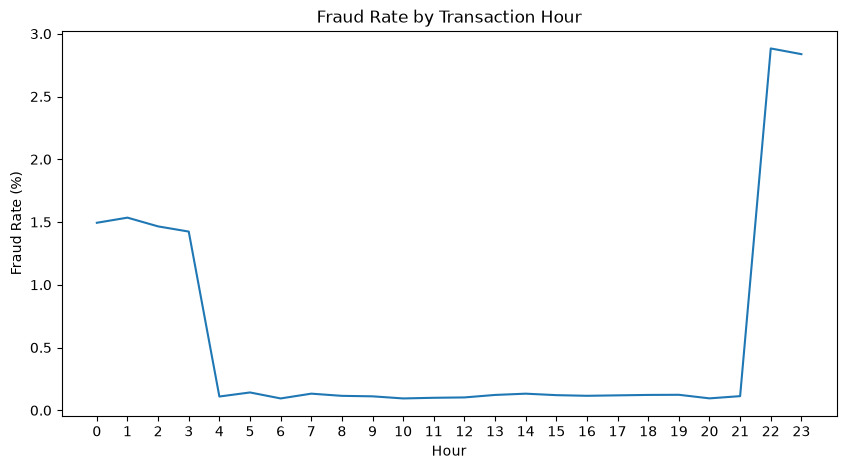

In [62]:
plt.figure(figsize=(10, 5))
fraud_by_hour.plot()
plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))
plt.show()

In [63]:
fraud_by_day = (data.groupby("transaction_dayofweek")["is_fraud"].mean().mul(100))

fraud_by_day

transaction_dayofweek
0    0.464838
1    0.583547
2    0.655360
3    0.684387
4    0.708600
5    0.610578
6    0.485276
Name: is_fraud, dtype: float64

In [64]:
day_names = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

fraud_by_day = (data.groupby("transaction_dayofweek")["is_fraud"].mean().mul(100).rename(index=day_names))

fraud_by_day

transaction_dayofweek
Monday       0.464838
Tuesday      0.583547
Wednesday    0.655360
Thursday     0.684387
Friday       0.708600
Saturday     0.610578
Sunday       0.485276
Name: is_fraud, dtype: float64

In [65]:
data.describe()

,Unnamed: 0,trans_date_trans_time,cc_num,amt,zip,lat,long,city_pop,unix_time,merch_lat,merch_long,is_fraud,transaction_hour,transaction_day,transaction_month,transaction_dayofweek
count,1.296675e+06,1296675,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06,1.296675e+06
mean,6.483370e+05,2019-10-03 12:47:28.070213,4.171920e+17,7.035104e+01,4.880067e+04,3.853762e+01,-9.022634e+01,8.882444e+04,1.349244e+09,3.853734e+01,-9.022646e+01,5.788652e-03,1.280486e+01,1.558798e+01,6.142150e+00,3.070604e+00
min,0.000000e+00,2019-01-01 00:00:18,6.041621e+10,1.000000e+00,1.257000e+03,2.002710e+01,-1.656723e+02,2.300000e+01,1.325376e+09,1.902779e+01,-1.666712e+02,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00
25%,3.241685e+05,2019-06-03 19:12:22.500000,1.800429e+14,9.650000e+00,2.623700e+04,3.462050e+01,-9.679800e+01,7.430000e+02,1.338751e+09,3.473357e+01,-9.689728e+01,0.000000e+00,7.000000e+00,8.000000e+00,3.000000e+00,1.000000e+00
50%,6.483370e+05,2019-10-03 07:35:47,3.521417e+15,4.752000e+01,4.817400e+04,3.935430e+01,-8.747690e+01,2.456000e+03,1.349250e+09,3.936568e+01,-8.743839e+01,0.000000e+00,1.400000e+01,1.500000e+01,6.000000e+00,3.000000e+00
75%,9.725055e+05,2020-01-28 15:02:55.500000,4.642255e+15,8.314000e+01,7.204200e+04,4.194040e+01,-8.015800e+01,2.032800e+04,1.359385e+09,4.195716e+01,-8.023680e+01,0.000000e+00,1.900000e+01,2.300000e+01,9.000000e+00,5.000000e+00
max,1.296674e+06,2020-06-21 12:13:37,4.992346e+18,2.894890e+04,9.978300e+04,6.669330e+01,-6.795030e+01,2.906700e+06,1.371817e+09,6.751027e+01,-6.695090e+01,1.000000e+00,2.300000e+01,3.100000e+01,1.200000e+01,6.000000e+00
std,3.743180e+05,NaN,1.308806e+18,1.603160e+02,2.689322e+04,5.075808e+00,1.375908e+01,3.019564e+05,1.284128e+07,5.109788e+00,1.377109e+01,7.586269e-02,6.817824e+00,8.829121e+00,3.417703e+00,2.198153e+00


Distribution analysis

In [66]:
features_to_check = [
    "amt",
    "city_pop",
    "lat",
    "long",
    "merch_lat",
    "merch_long"
]

for col in features_to_check:
    print(f"\n{col}")
    print(f"Skewness : {data[col].skew():.4f}")
    print(f"Kurtosis : {data[col].kurtosis():.4f}")


amt
Skewness : 42.2779
Kurtosis : 4545.6450

city_pop
Skewness : 5.5939
Kurtosis : 37.6145

lat
Skewness : -0.1860
Kurtosis : 0.8130

long
Skewness : -1.1501
Kurtosis : 1.8559

merch_lat
Skewness : -0.1819
Kurtosis : 0.7960

merch_long
Skewness : -1.1470
Kurtosis : 1.8485


#######################################  Outliers ############################################################## 

<Axes: ylabel='amt'>

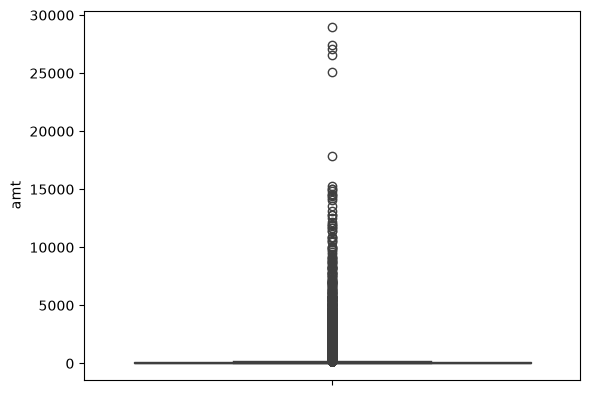

In [67]:
sns.boxplot(data['amt'])

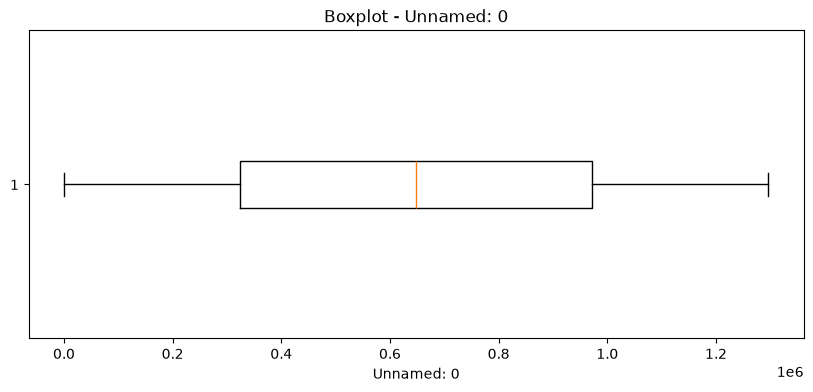

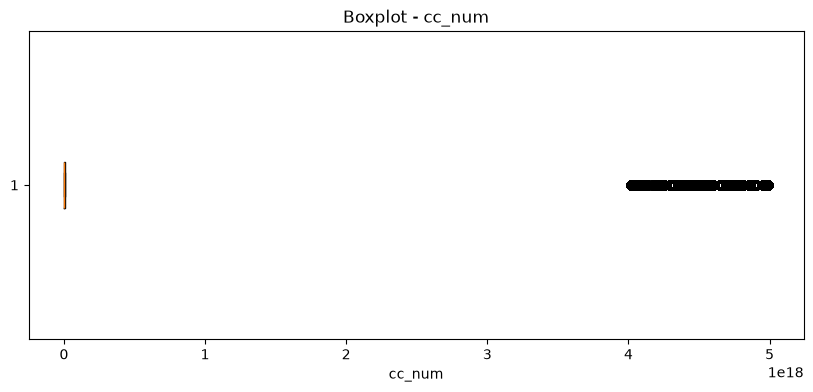

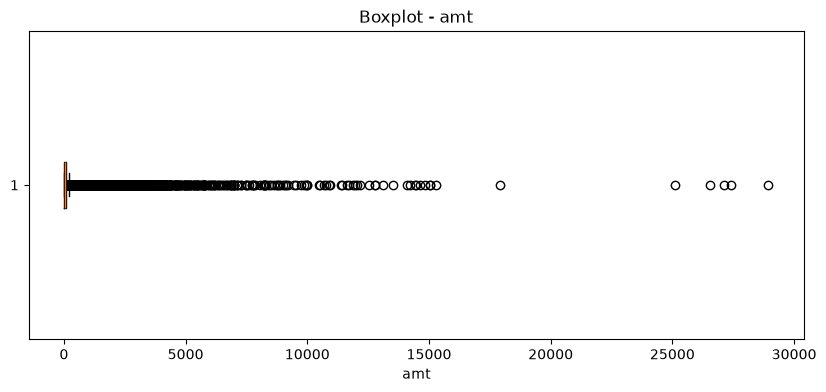

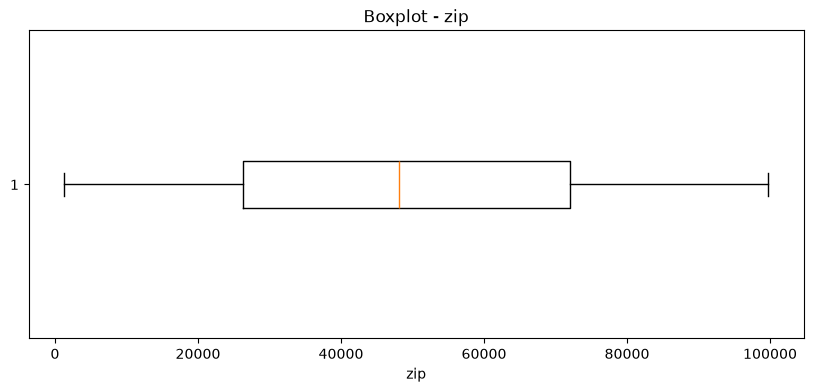

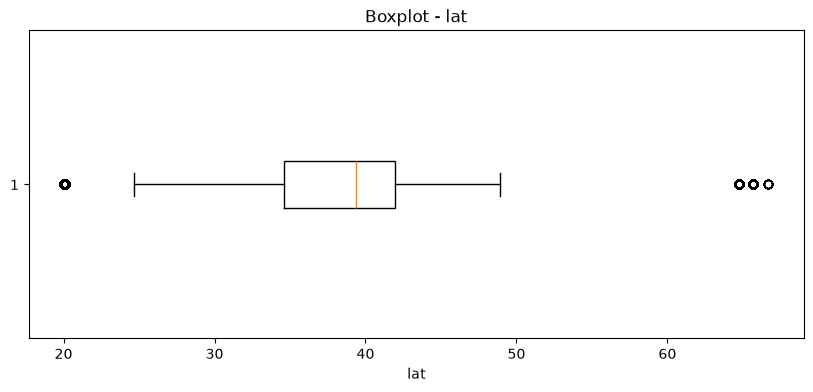

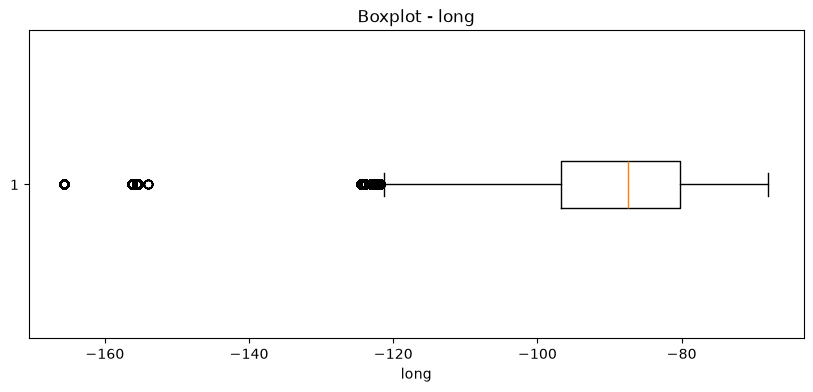

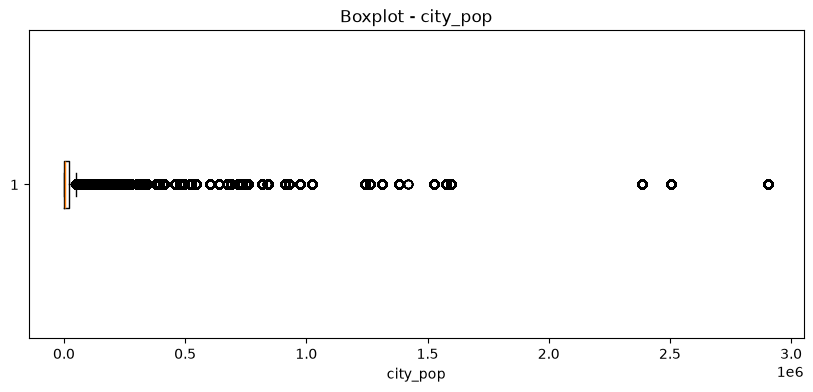

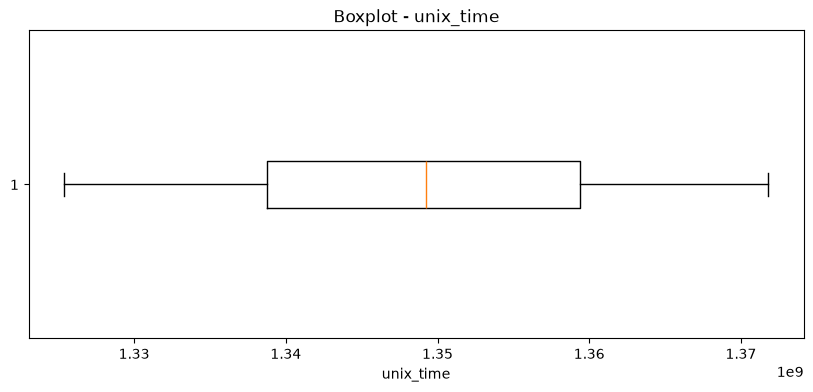

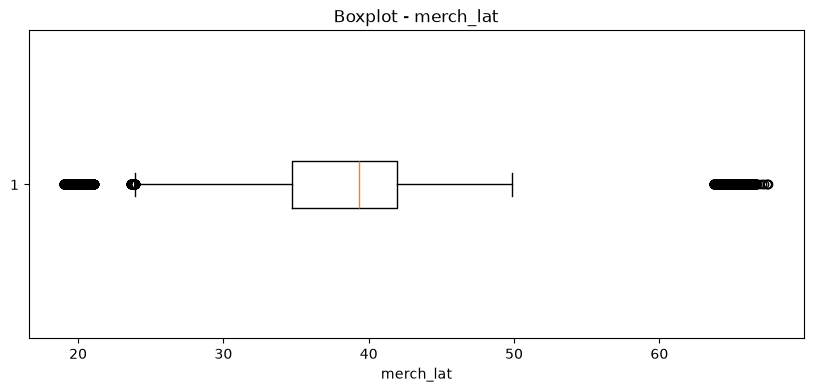

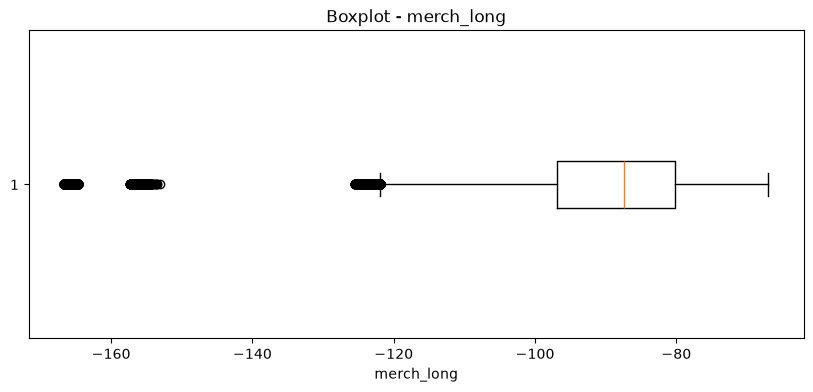

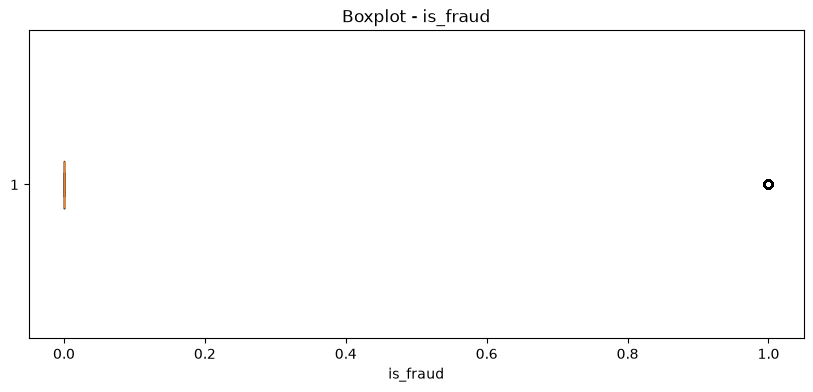

In [68]:
for col in numeric_col:
    plt.figure(figsize=(10,4))
    plt.boxplot(data[col].dropna(), vert=False)
    plt.title(f"Boxplot - {col}")
    plt.xlabel(col)
    plt.show()